In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm
DTYPE = 'float32'
tf.keras.backend.set_floatx(DTYPE)

In [2]:
K = 100.0       # Strike price
r = 0.05        # Risk-free interest rate
sigma = 0.20    # Volatility
T = 1.0         # Time to maturity (in years)

# Domain boundaries
S_min = 0.0
S_max = 200.0
t_min = 0.0
t_max = T

In [3]:
def build_model(num_hidden_layers=4, num_neurons=20):
    model = tf.keras.Sequential()
    
    # Input layer takes 2 features: t (time) and S (stock price)
    model.add(tf.keras.layers.InputLayer(input_shape=(2,)))
    
    # Hidden layers
    for _ in range(num_hidden_layers):
        model.add(tf.keras.layers.Dense(num_neurons, activation='tanh',
                                        kernel_initializer='glorot_normal'))
        
    # Output layer produces 1 value: V
    model.add(tf.keras.layers.Dense(1))
    
    return model

# Instantiate the model
pinn_model = build_model()
pinn_model.summary()

C:\Users\user\anaconda3\Lib\site-packages\keras\src\layers\core\input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 20)                  │              60 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 20)                  │             420 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 1)                   │              21 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,341 (5.24 KB)

 Trainable params: 1,341 (5.24 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
def pde_residual(model, t, S):
    with tf.GradientTape(persistent=True) as tape:
        tape.watch([t, S])
        with tf.GradientTape(persistent=True) as inner_tape:
            inner_tape.watch([t, S])
            V = model(tf.stack([t, S], axis=1))
        
        # First-order derivatives
        V_t = inner_tape.gradient(V, t)
        V_S = inner_tape.gradient(V, S)
    
    # Second-order derivative
    V_SS = tape.gradient(V_S, S)
    
    del tape 
    residual = V_t + 0.5 * sigma**2 * S**2 * V_SS + r * S * V_S - r * V
    return residual

def loss_fn(model, t_col, S_col, t_ter, S_ter, t_bnd, S_bnd):
    #Computes the total loss
    # PDE residual loss at collocation points
    pde_res = pde_residual(model, t_col, S_col)
    loss_pde = tf.reduce_mean(tf.square(pde_res))
    
    # Terminal condition loss (at t=T)
    V_pred_ter = model(tf.stack([t_ter, S_ter], axis=1))
    payoff = tf.maximum(S_ter - K, 0.0)
    loss_terminal = tf.reduce_mean(tf.square(V_pred_ter - payoff))

    # Boundary condition loss
    # At S=0, V must be 0
    V_pred_bnd_zero = model(tf.stack([t_bnd, S_bnd[0]], axis=1))
    loss_bnd_zero = tf.reduce_mean(tf.square(V_pred_bnd_zero))
    
    # At S=S_max, V should be S - K*exp(-r*(T-t))
    V_pred_bnd_max = model(tf.stack([t_bnd, S_bnd[1]], axis=1))
    V_true_bnd_max = S_bnd[1] - K * tf.exp(-r * (T - t_bnd))
    loss_bnd_max = tf.reduce_mean(tf.square(V_pred_bnd_max - V_true_bnd_max))
    
    # Total loss is the sum of all components
    total_loss = loss_pde + loss_terminal + loss_bnd_zero + loss_bnd_max
    return total_loss

In [5]:
# Number of training points
N_collocation = 20000
N_boundary = 2500
N_terminal = 5000

# Collocation points (for PDE residual)
t_col = tf.random.uniform(shape=(N_collocation, 1), minval=t_min, maxval=t_max, dtype=DTYPE)
S_col = tf.random.uniform(shape=(N_collocation, 1), minval=S_min, maxval=S_max, dtype=DTYPE)

# Terminal condition points (t=T)
t_ter = tf.constant(T, shape=(N_terminal, 1), dtype=DTYPE)
S_ter = tf.random.uniform(shape=(N_terminal, 1), minval=S_min, maxval=S_max, dtype=DTYPE)

# Boundary condition points (S=0 and S=S_max)
t_bnd = tf.random.uniform(shape=(N_boundary, 1), minval=t_min, maxval=t_max, dtype=DTYPE)
S_bnd_zero = tf.constant(S_min, shape=(N_boundary, 1), dtype=DTYPE)
S_bnd_max = tf.constant(S_max, shape=(N_boundary, 1), dtype=DTYPE)
S_bnd = [S_bnd_zero, S_bnd_max]

In [6]:
# Training parameters
epochs = 5000
learning_rate = tf.keras.optimizers.schedules.ExponentialDecay(
    initial_learning_rate=1e-3,
    decay_steps=500,
    decay_rate=0.9
)
optimizer = tf.keras.optimizers.Adam(learning_rate=learning_rate)

@tf.function
def train_step(model):
    with tf.GradientTape() as tape:
        loss = loss_fn(model, t_col, S_col, t_ter, S_ter, t_bnd, S_bnd)
    
    # Compute gradients and update weights
    gradients = tape.gradient(loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    return loss

# Training loop
for epoch in range(epochs):
    loss_value = train_step(pinn_model)
    if (epoch + 1) % 500 == 0:
        print(f"Epoch {epoch + 1}, Loss: {loss_value.numpy():.4e}")

Epoch 500, Loss: 8.7558e+03
Epoch 1000, Loss: 7.0191e+03
Epoch 1500, Loss: 5.7163e+03
Epoch 2000, Loss: 4.7067e+03
Epoch 2500, Loss: 3.9099e+03
Epoch 3000, Loss: 3.2723e+03
Epoch 3500, Loss: 2.7565e+03
Epoch 4000, Loss: 2.3357e+03
Epoch 4500, Loss: 1.9903e+03
Epoch 5000, Loss: 1.7052e+03


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step


C:\Users\user\AppData\Local\Temp\ipykernel_3084\1564970071.py:5: RuntimeWarning: divide by zero encountered in log
  d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * (T - t)) / (sigma * np.sqrt(T - t))


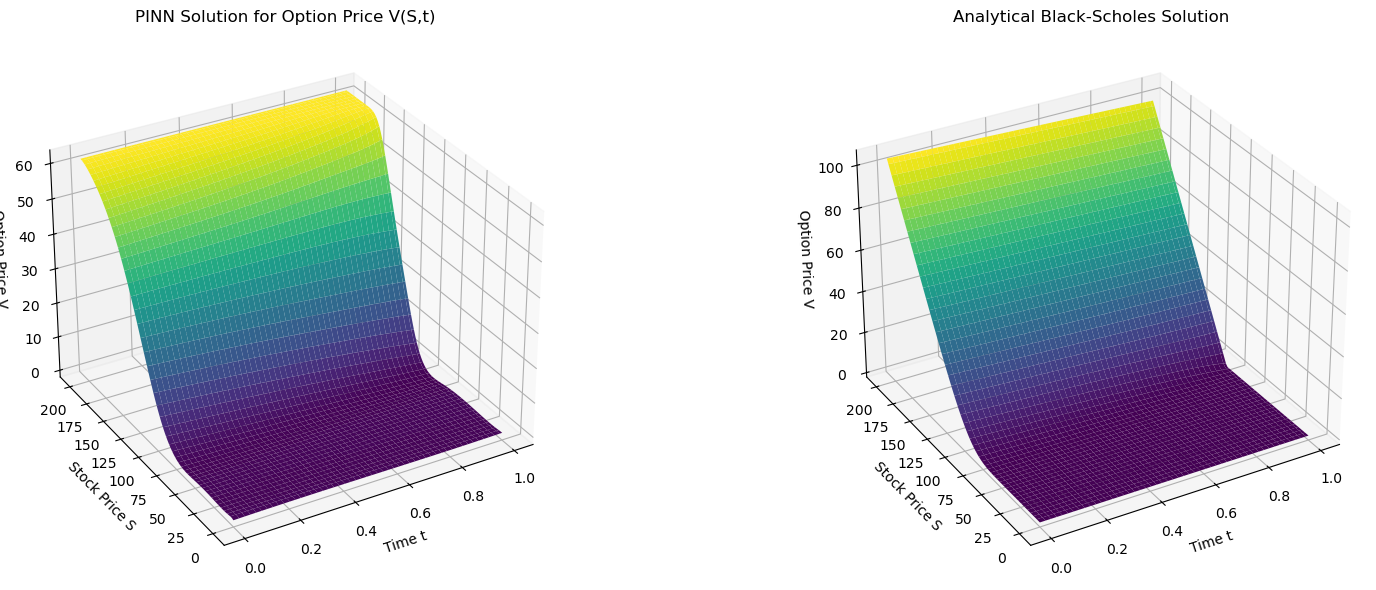

In [7]:
def black_scholes_analytical(S, t, K, r, sigma, T):
    """Analytical solution for European call option."""
    if t == T:
        return np.maximum(S - K, 0)
    d1 = (np.log(S / K) + (r + 0.5 * sigma**2) * (T - t)) / (sigma * np.sqrt(T - t))
    d2 = d1 - sigma * np.sqrt(T - t)
    call_price = (S * norm.cdf(d1) - K * np.exp(-r * (T - t)) * norm.cdf(d2))
    return call_price

# Create a grid for plotting
S_plot = np.linspace(S_min, S_max, 100)
t_plot = np.linspace(t_min, t_max, 100)
S_grid, t_grid = np.meshgrid(S_plot, t_plot)
grid_points = np.stack([t_grid.flatten(), S_grid.flatten()], axis=1)

# Predict using the trained PINN
V_pred = pinn_model.predict(grid_points).reshape(S_grid.shape)

# Calculate analytical solution
V_analytical = np.zeros_like(S_grid)
for i in range(len(t_plot)):
    for j in range(len(S_plot)):
        V_analytical[i, j] = black_scholes_analytical(S_grid[i, j], t_grid[i, j], K, r, sigma, T)

# Plotting
fig = plt.figure(figsize=(18, 6))

# PINN Solution
ax1 = fig.add_subplot(1, 2, 1, projection='3d')
ax1.plot_surface(t_grid, S_grid, V_pred, cmap='viridis')
ax1.set_title('PINN Solution for Option Price V(S,t)')
ax1.set_xlabel('Time t')
ax1.set_ylabel('Stock Price S')
ax1.set_zlabel('Option Price V')
ax1.view_init(30, -120)

# Analytical Solution
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.plot_surface(t_grid, S_grid, V_analytical, cmap='viridis')
ax2.set_title('Analytical Black-Scholes Solution')
ax2.set_xlabel('Time t')
ax2.set_ylabel('Stock Price S')
ax2.set_zlabel('Option Price V')
ax2.view_init(30, -120)

plt.tight_layout()
plt.show()

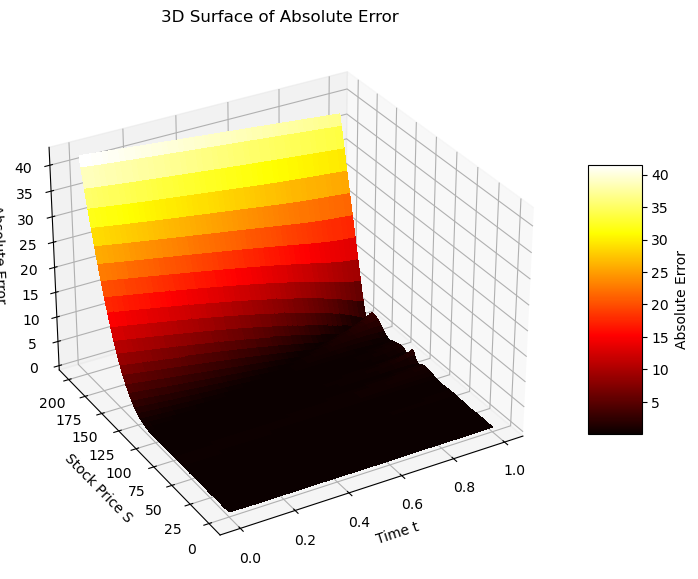

In [8]:
fig_err = plt.figure(figsize=(10, 7))
ax_err = fig_err.add_subplot(111, projection='3d')

# The absolute error between the two solutions
difference = np.abs(V_pred - V_analytical)

# Create the 3D surface plot for the error
surf_err = ax_err.plot_surface(t_grid, S_grid, difference, cmap='hot', linewidth=0, antialiased=False)

# Set titles and labels
ax_err.set_title('3D Surface of Absolute Error')
ax_err.set_xlabel('Time t')
ax_err.set_ylabel('Stock Price S')
ax_err.set_zlabel('Absolute Error')

# Add a color bar which maps values to colors.
fig_err.colorbar(surf_err, shrink=0.5, aspect=5, label='Absolute Error')

# Set viewing angle
ax_err.view_init(30, -120)

plt.show()